# 🔐 Predictive Modeling of Crypto-System Vulnerabilities
## End-to-End Machine Learning Pipeline
**Authors:** Eileen Rashduni · Atharv Koratkar

This notebook walks through every stage of the pipeline:

| Stage | Description |
|-------|-------------|
| **Stage 1** | Data Ingestion — load & harmonise all 6 real datasets |
| **Stage 2** | EDA — visualise raw breach data |
| **Stage 3** | Feature Engineering — build model-ready feature matrix |
| **Stage 4** | Feature Analysis — correlation, distribution, importance |
| **Stage 5** | Walk-Forward Model Training — 5 models × time-series CV |
| **Stage 6** | Evaluation — Brier Score, Log-Loss, PR-AUC |
| **Stage 7** | Explainability — feature importance & SHAP-style analysis |
| **Stage 8** | Risk Scoring — probability output & alert tier |


## ⚙️ Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Add project root to path
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML

# Inline plotting
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']
print('Environment ready ✓')
print(f'  numpy  {np.__version__}')
print(f'  pandas {pd.__version__}')
import sklearn; print(f'  sklearn {sklearn.__version__}')


Environment ready ✓
  numpy  2.4.3
  pandas 3.0.1
  sklearn 1.8.0


---
## 📥 Stage 1 — Data Ingestion

We load and harmonise **6 independent datasets**:

| ID | Source | Records | Description |
|----|--------|---------|-------------|
| IIB | Information is Beautiful | ~440 | High-profile global breaches 2004–2022 |
| HHS | HHS / OCR | ~1 285 | US Healthcare breaches 2009–present |
| DBN | DataBreachN | ~352 | International, country-level |
| DBEN | DataBreach EU | ~277 | European registry 2004–2017 |
| DF1 | Wikipedia Extended | ~352 | Broad entity list |
| CSIS | CSIS PDF | text-mined | State-sponsored / major incidents 2006–2025 |


In [2]:
from data_ingestion import load_all_datasets, flag_crypto, categorise_method

df = load_all_datasets(data_dir='data')

print(f'\n✅ Total records loaded: {len(df):,}')
print(f'   Year range:           {df["year"].min()} – {df["year"].max()}')
print(f'   Crypto-related:       {df["is_crypto"].sum():,} ({df["is_crypto"].mean()*100:.1f}%)')
print(f'   Source breakdown:')
print(df['source_id'].value_counts().to_string())


  pypdf extraction error: cryptography>=3.1 is required for AES algorithm



✅ Total records loaded: 1,825
   Year range:           2004 – 2025
   Crypto-related:       61 (3.3%)
   Source breakdown:
source_id
HHS     883
IIB     416
DBN     274
CSIS    207
DBEN     37
DF1       8


In [3]:
# Preview the unified DataFrame
display(HTML('<b>Unified Breach DataFrame (first 10 rows)</b>'))
display(df.head(10).style.background_gradient(subset=['records_affected'], cmap='Blues'))


,year,entity,sector_raw,sector,method_raw,method_category,records_affected,is_crypto,source_id
0,2022,Plex,web,tech_web,hacked,hacking,15000000.000000,False,IIB
1,2021,Twitter,web,tech_web,hacked,hacking,5400000.000000,False,IIB
2,2022,Shanghai Police,financial,financial,hacked,hacking,500000000.000000,False,IIB
3,2022,"City of Amagasaki, Japan",government,government,oops!,poor_security,500000.000000,False,IIB
4,2022,Dubai Real Estate Leak,financial,financial,inside job,insider,800000.000000,False,IIB
5,2022,Heroku,tech,tech_web,hacked,hacking,50000.000000,True,IIB
6,2022,Mailchimp,tech,tech_web,hacked,hacking,106586.000000,False,IIB
7,2022,PayHere,financial,financial,hacked,hacking,1580249.000000,False,IIB
8,2022,CDEK,retail,retail,hacked,hacking,18218203.000000,False,IIB
9,2022,Washington State Dpt of Licensing,government,government,hacked,hacking,257000.000000,False,IIB


In [4]:
# Data quality summary
print('=== Data Quality ===')
print(df.dtypes.to_string())
print('\nNull counts:')
print(df.isnull().sum().to_string())
print(f'\nMethod categories: {sorted(df["method_category"].unique())}')
print(f'Sectors:           {sorted(df["sector"].unique())}')


=== Data Quality ===
year                  int64
entity                  str
sector_raw              str
sector                  str
method_raw              str
method_category         str
records_affected    float64
is_crypto              bool
source_id               str

Null counts:
year                  0
entity                0
sector_raw            0
sector                0
method_raw            0
method_category       0
records_affected    196
is_crypto             0
source_id             0

Method categories: ['ddos', 'hacking', 'insider', 'lost_device', 'malware', 'other', 'phishing', 'poor_security', 'supply_chain', 'unauthorized_access']
Sectors:           ['academic', 'energy', 'financial', 'gaming', 'government', 'healthcare', 'legal', 'media', 'other', 'retail', 'social_media', 'tech_web', 'telecom', 'transport']


---
## 📊 Stage 2 — Exploratory Data Analysis

Visualise the raw breach landscape before any feature engineering.


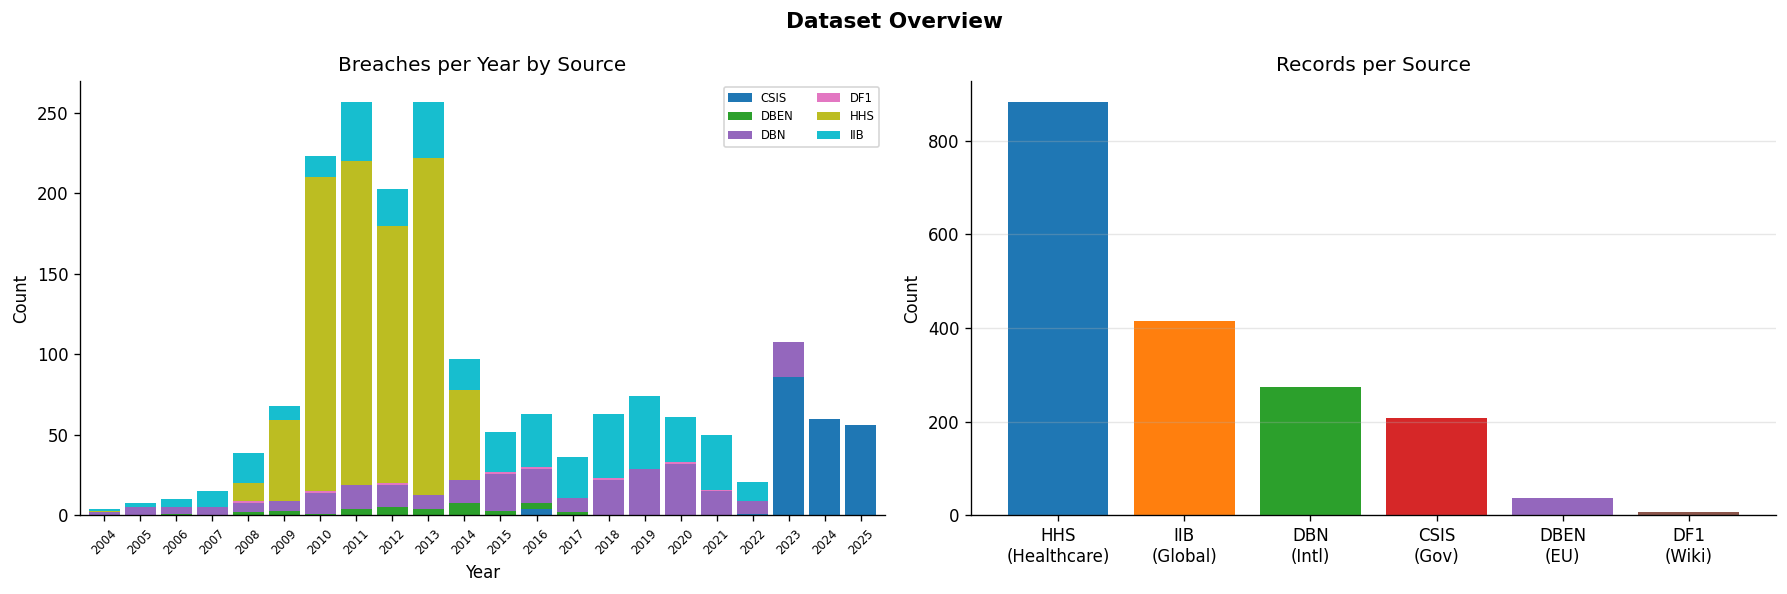

In [5]:
# ── 2A: Breach counts by year, coloured by source ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Dataset Overview', fontsize=13, fontweight='bold')

yr_src = df.groupby(['year','source_id']).size().unstack(fill_value=0)
yr_src.plot(kind='bar', stacked=True, ax=axes[0],
            colormap='tab10', legend=True, width=0.85)
axes[0].set_title('Breaches per Year by Source')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=7, ncol=2)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

src_cnt = df['source_id'].value_counts()
src_labels = {'IIB':'IIB\n(Global)','HHS':'HHS\n(Healthcare)',
              'DBN':'DBN\n(Intl)','DBEN':'DBEN\n(EU)',
              'DF1':'DF1\n(Wiki)','CSIS':'CSIS\n(Gov)'}
axes[1].bar([src_labels.get(s,s) for s in src_cnt.index],
            src_cnt.values, color=PALETTE)
axes[1].set_title('Records per Source'); axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


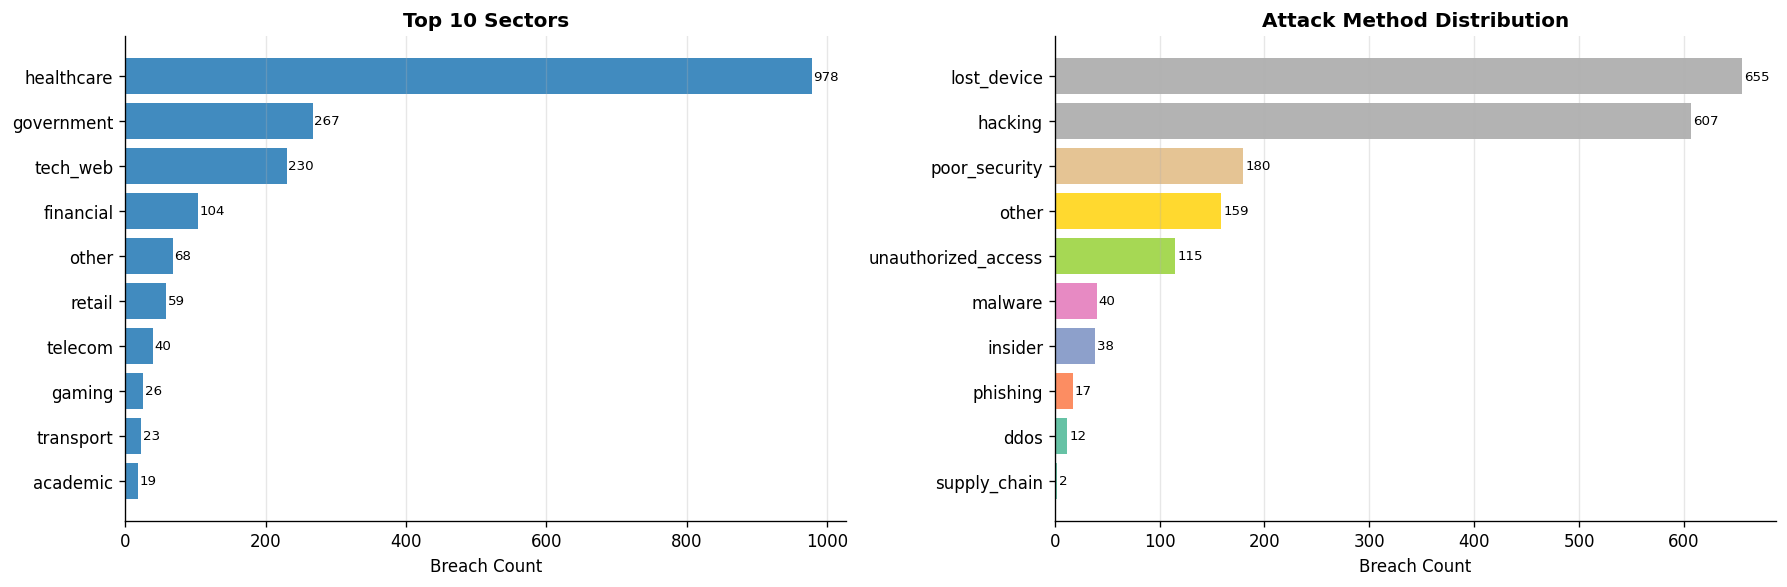

In [6]:
# ── 2B: Sector & Method distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sec = df['sector'].value_counts().head(10)
axes[0].barh(sec.index[::-1], sec.values[::-1], color='#1f77b4', alpha=0.85)
axes[0].set_title('Top 10 Sectors', fontweight='bold')
axes[0].set_xlabel('Breach Count'); axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(sec.values[::-1]):
    axes[0].text(v+2, i, str(v), va='center', fontsize=8)

meth = df['method_category'].value_counts().head(10)
colours = plt.cm.Set2(np.linspace(0, 1, len(meth)))
axes[1].barh(meth.index[::-1], meth.values[::-1], color=colours)
axes[1].set_title('Attack Method Distribution', fontweight='bold')
axes[1].set_xlabel('Breach Count'); axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(meth.values[::-1]):
    axes[1].text(v+2, i, str(v), va='center', fontsize=8)

plt.tight_layout(); plt.show()


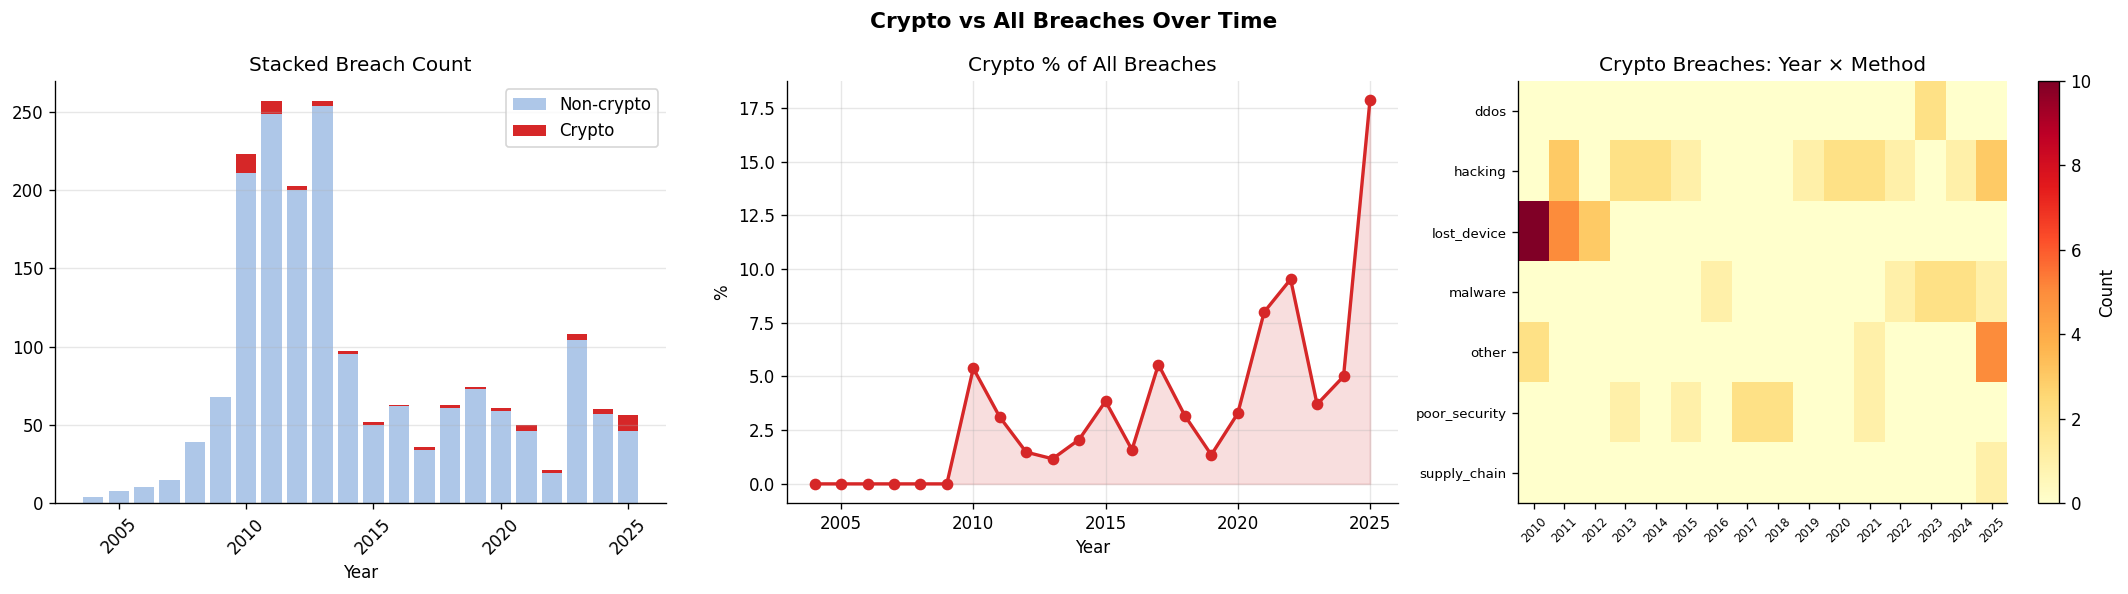

In [7]:
# ── 2C: Crypto vs Non-Crypto over time ─────────────────────────────────
yr = df.groupby('year')
total  = yr.size().rename('total')
crypto = yr['is_crypto'].sum().rename('crypto')
comb   = pd.concat([total, crypto], axis=1).fillna(0)
comb['non_crypto'] = comb['total'] - comb['crypto']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Crypto vs All Breaches Over Time', fontsize=13, fontweight='bold')

ax1.bar(comb.index, comb['non_crypto'], label='Non-crypto', color='#aec7e8')
ax1.bar(comb.index, comb['crypto'], bottom=comb['non_crypto'],
        label='Crypto', color='#d62728')
ax1.set_title('Stacked Breach Count'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)
ax1.set_xlabel('Year'); ax1.tick_params(axis='x', rotation=45)

pct = (comb['crypto'] / comb['total'].replace(0,1)) * 100
ax2.plot(pct.index, pct.values, 'o-', color='#d62728', linewidth=2)
ax2.fill_between(pct.index, pct.values, alpha=0.15, color='#d62728')
ax2.set_title('Crypto % of All Breaches'); ax2.set_ylabel('%')
ax2.set_xlabel('Year'); ax2.grid(alpha=0.3)

# Heatmap: method × year (crypto only)
crypto_df = df[df['is_crypto']]
if len(crypto_df) > 0:
    heat = crypto_df.groupby(['year','method_category']).size().unstack(fill_value=0)
    im = ax3.imshow(heat.T, aspect='auto', cmap='YlOrRd')
    ax3.set_yticks(range(len(heat.columns)))
    ax3.set_yticklabels(heat.columns, fontsize=8)
    ax3.set_xticks(range(len(heat.index)))
    ax3.set_xticklabels(heat.index, rotation=45, fontsize=7)
    ax3.set_title('Crypto Breaches: Year × Method')
    plt.colorbar(im, ax=ax3, label='Count')

plt.tight_layout(); plt.show()


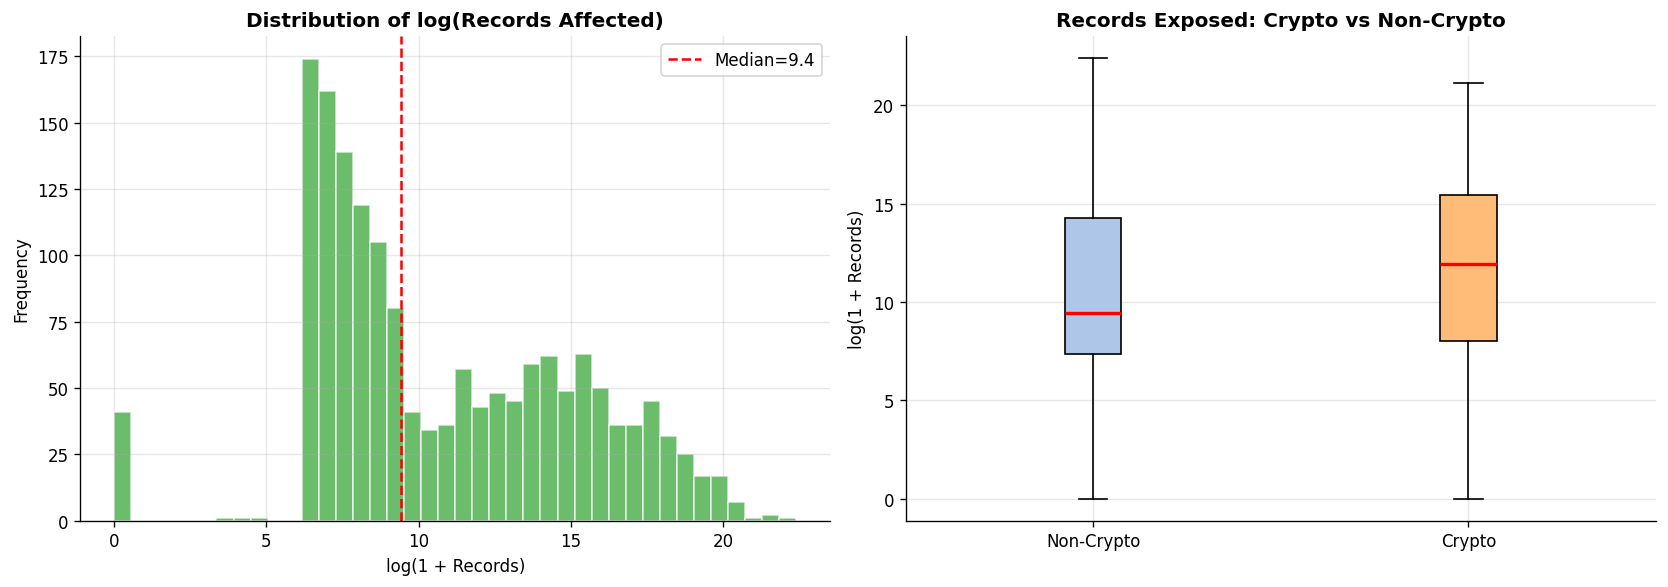

Crypto median records:     907,021,739,732
Non-crypto median records: 2,611,113,839


In [8]:
# ── 2D: Records exposed distribution (log scale) ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of log(records)
log_rec = np.log1p(df['records_affected'].dropna())
ax1.hist(log_rec, bins=40, color='#2ca02c', alpha=0.7, edgecolor='white')
ax1.set_title('Distribution of log(Records Affected)', fontweight='bold')
ax1.set_xlabel('log(1 + Records)'); ax1.set_ylabel('Frequency')
ax1.axvline(log_rec.median(), color='red', linestyle='--', label=f'Median={log_rec.median():.1f}')
ax1.legend(); ax1.grid(alpha=0.3)

# Crypto vs non-crypto record comparison (box plot)
# Cast to bool first to avoid bitwise NOT issue on mixed-type columns
is_crypto_mask = df['is_crypto'].astype(bool)
crypto_rec  = np.log1p(df[is_crypto_mask]['records_affected'].dropna())
ncrypto_rec = np.log1p(df[~is_crypto_mask]['records_affected'].dropna())
bp = ax2.boxplot([ncrypto_rec, crypto_rec],
                 labels=['Non-Crypto', 'Crypto'],
                 patch_artist=True,
                 boxprops=dict(facecolor='#aec7e8'),
                 medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('#ffbb78')
ax2.set_title('Records Exposed: Crypto vs Non-Crypto', fontweight='bold')
ax2.set_ylabel('log(1 + Records)'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Crypto median records:     {10**crypto_rec.median():,.0f}')
print(f'Non-crypto median records: {10**ncrypto_rec.median():,.0f}')


---
## 🔧 Stage 3 — Feature Engineering

Transform the raw incident table into a **yearly feature matrix** suitable for ML:

- Annual breach counts, crypto fraction, log-records
- **Sector one-hot fractions** (7 sectors)
- **Method one-hot fractions** (10 attack types)
- **Lag features** (1-year, 2-year) for key indicators
- **Rolling mean/std** windows (2, 3 years)
- **Interaction terms**: hacking × financial, records × crypto count
- **Year-over-year growth** rates

Label: `1` if ≥1 crypto breach occurred that year.


In [9]:
from feature_engineering import build_feature_matrix

X, y, feature_names, scaler, yearly_df = build_feature_matrix(
    df, target_mode='crypto_binary', scale=True
)

print(f'Feature matrix shape: {X.shape}')
print(f'Years covered:        {X.index.min()} – {X.index.max()}')
print(f'Positive class rate:  {y.mean():.2%}  ({y.sum()} / {len(y)} years had crypto breaches)')
print(f'\nFirst 5 feature names: {feature_names[:5]}')
print(f'Last 5 feature names:  {feature_names[-5:]}')


Feature matrix shape: (22, 62)
Years covered:        2004 – 2025
Positive class rate:  63.64%  (14 / 22 years had crypto breaches)

First 5 feature names: ['log_records_total', 'mean_records', 'log_max_records', 'unique_entities', 'unique_methods']
Last 5 feature names:  ['breach_trend_slope', 'crypto_trend_slope', 'crypto_momentum', 'hacking_x_financial', 'crypto_slope_x_volatility']


In [10]:
# Show the yearly aggregated DataFrame
display(HTML('<b>Yearly Aggregated Feature Table</b>'))
display(
    yearly_df[['total_breaches','crypto_breach_count','crypto_fraction',
               'log_records_total','unique_entities','unique_methods']]
    .style
    .background_gradient(subset=['crypto_breach_count'], cmap='Reds')
    .background_gradient(subset=['total_breaches'], cmap='Blues')
    .format({'crypto_fraction': '{:.1%}', 'log_records_total': '{:.2f}'})
)


,total_breaches,crypto_breach_count,crypto_fraction,log_records_total,unique_entities,unique_methods
year,,,,,,
2004,4,0.000000,0.0%,19.03,3,3
2005,8,0.000000,0.0%,18.28,8,3
2006,10,0.000000,0.0%,18.56,10,5
2007,15,0.000000,0.0%,18.89,15,3
2008,39,0.000000,0.0%,18.65,39,6
2009,68,0.000000,0.0%,19.66,67,5
2010,223,12.000000,5.4%,17.18,219,6
2011,257,8.000000,3.1%,19.76,250,6
2012,203,3.000000,1.5%,20.89,199,6


In [11]:
# Show scaled feature matrix
display(HTML('<b>Scaled Feature Matrix (first 5 columns, all years)</b>'))
display(
    X.iloc[:, :8]
    .style
    .background_gradient(cmap='RdBu_r', axis=0)
    .format('{:.3f}')
)


,log_records_total,mean_records,log_max_records,unique_entities,unique_methods,source_diversity,large_breach_count,sector_financial
year,,,,,,,,
2004,-0.962,-0.221,-0.581,-1.043,-1.399,-0.189,-1.332,-0.704
2005,-1.459,-0.253,-1.059,-0.977,-1.399,-1.020,-1.118,4.114
2006,-1.276,-0.252,-1.296,-0.950,0.033,-0.189,-0.976,0.948
2007,-1.057,-0.253,-0.569,-0.884,-1.399,-1.020,-0.763,0.764
2008,-1.216,-0.260,-1.518,-0.566,0.748,1.473,0.019,0.426
2009,-0.549,-0.258,-0.383,-0.195,0.033,0.642,-0.621,-0.542
2010,-2.191,-0.262,-2.492,1.821,0.748,1.473,-0.763,-0.580
2011,-0.482,-0.261,-0.683,2.232,0.748,0.642,0.517,-0.639
2012,0.271,-0.257,-0.135,1.556,0.748,1.473,0.517,-0.487


---
## 🔍 Stage 4 — Feature Analysis

Examine feature distributions, correlations, and predictive value
before fitting any model.


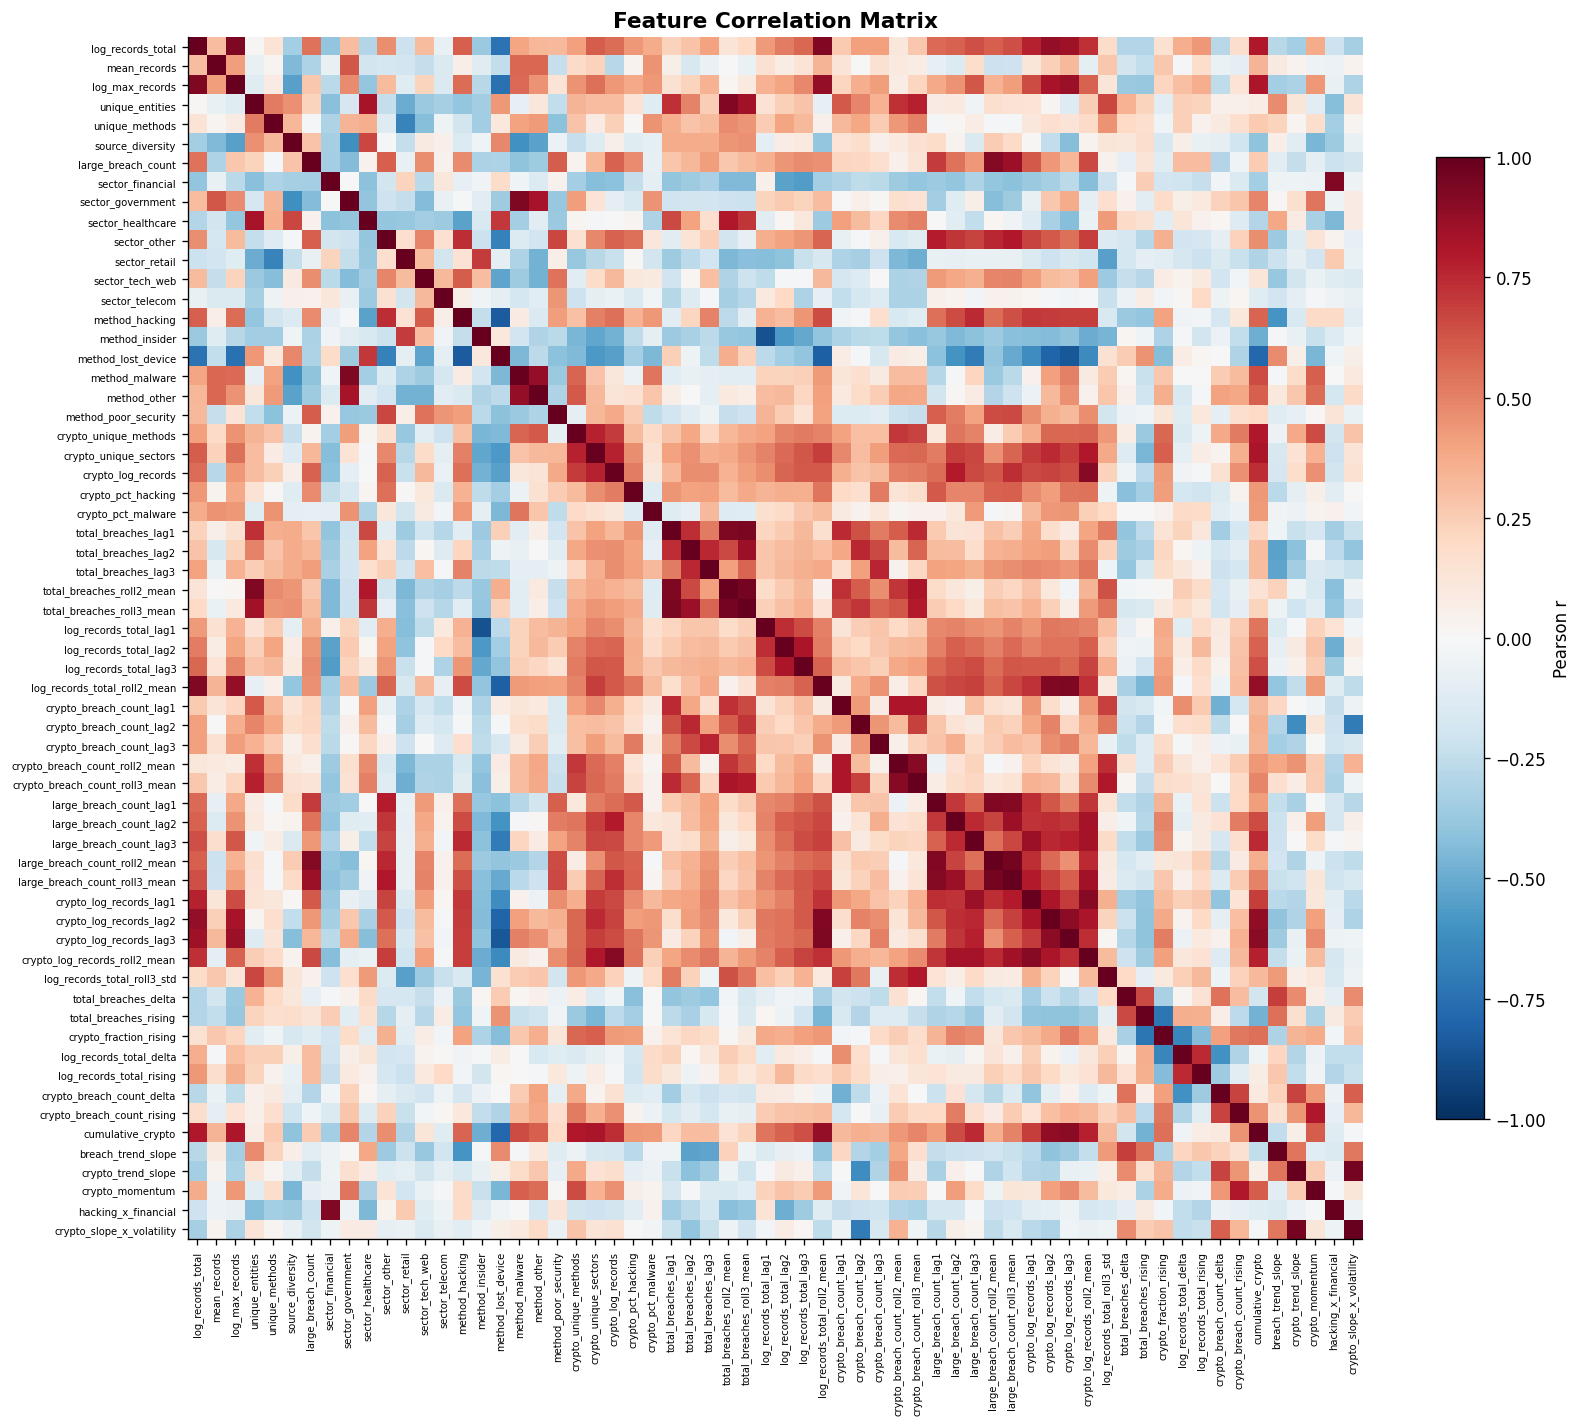

In [12]:
# ── 4A: Feature correlation heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
corr = X.corr()
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


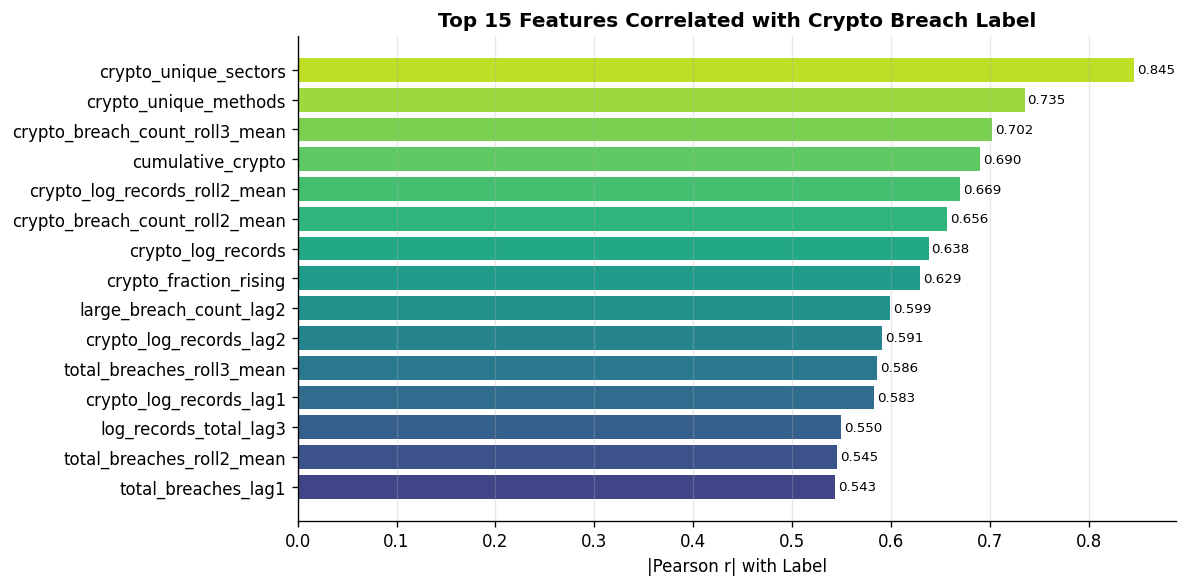

In [13]:
# ── 4B: Feature-label correlation (Pearson r with y) ──────────────────
corr_y = X.corrwith(y.astype(float)).abs().sort_values(ascending=False)
top15  = corr_y.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)))
ax.set_xlabel('|Pearson r| with Label')
ax.set_title('Top 15 Features Correlated with Crypto Breach Label',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


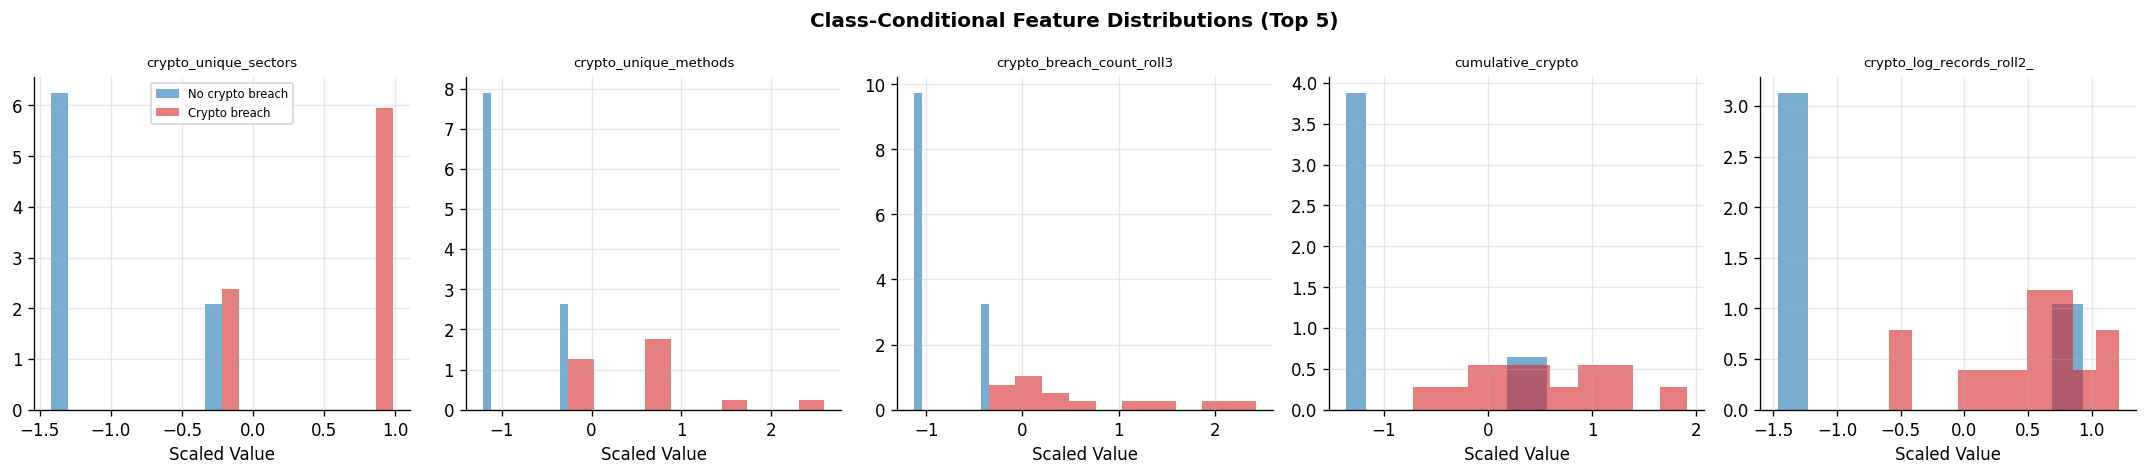

In [14]:
# ── 4C: Class-conditional feature distributions ────────────────────────
top5_feats = corr_y.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Class-Conditional Feature Distributions (Top 5)', fontweight='bold')

X_with_y = X.copy(); X_with_y['label'] = y
for ax, feat in zip(axes, top5_feats):
    for cls, colour, label in [(0,'#1f77b4','No crypto breach'),
                                (1,'#d62728','Crypto breach')]:
        vals = X_with_y[X_with_y['label']==cls][feat].dropna()
        ax.hist(vals, bins=10, alpha=0.6, color=colour, label=label, density=True)
    ax.set_title(feat[:25], fontsize=8)
    ax.set_xlabel('Scaled Value'); ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


---
## 🤖 Stage 5 — Walk-Forward Model Training

We train **5 models** using **walk-forward (expanding-window) time-series CV**:

```
Fold 0: Train 2004–2008 → Test 2009
Fold 1: Train 2004–2009 → Test 2010
...
Fold N: Train 2004–(last-1) → Test last year
```

No fold ever uses future data to train. Calibration is applied via isotonic regression.


In [15]:
from models import WalkForwardValidator, build_models

wfv = WalkForwardValidator(
    train_window=None,   # expanding window
    min_train_size=5,
    calibrate=False,
)

# v2 models: LogisticRegression, RandomForest, ExtraTrees, GradientBoosting, SVM
models = build_models()
results = wfv.fit_predict(X, y, models=models)

print(f'Folds run: {len(results)}')
print(f'Models:    {list(models.keys())}')


Folds run: 75
Models:    ['LogisticRegression', 'RidgeClassifier', 'RandomForest', 'ExtraTrees', 'GradientBoosting']


In [16]:
# Per-fold predictions table
preds_df = wfv.consolidated_predictions()
display(HTML('<b>Walk-Forward Predictions (first 20 rows)</b>'))
display(
    preds_df.head(20)
    .style
    .background_gradient(subset=['y_prob'], cmap='RdYlGn_r')
    .map(lambda v: 'color: red; font-weight: bold' if v == 1 else '',
        subset=['y_true'])
    .format({'y_prob': '{:.3f}'})
)


,year,model,fold,y_true,y_prob,high_risk
0,2011,LogisticRegression,7,1,0.600,1
1,2011,RidgeClassifier,7,1,0.539,1
2,2011,RandomForest,7,1,0.376,0
3,2011,ExtraTrees,7,1,0.580,1
4,2011,GradientBoosting,7,1,0.144,0
5,2012,LogisticRegression,8,1,0.589,1
6,2012,RidgeClassifier,8,1,0.541,1
7,2012,RandomForest,8,1,0.584,1
8,2012,ExtraTrees,8,1,0.686,1
9,2012,GradientBoosting,8,1,0.239,0


---
## 📏 Stage 6 — Evaluation Metrics

Three primary metrics from the project proposal (Section 5.3):

| Metric | Formula | Purpose |
|--------|---------|------|
| **Brier Score** | `mean((F_t − O_t)²)` | Calibration — lower is better |
| **Log-Loss** | `−mean[O·log F + (1−O)·log(1−F)]` | Penalises overconfidence |
| **PR-AUC** | Area under Precision-Recall curve | Best for rare positive class |


In [17]:
# Summary metrics across all models
summary = wfv.summary_metrics()
print('=== Walk-Forward Mean Metrics ===')
display(
    summary.style
    .highlight_min(subset=['brier','log_loss'], color='#c6efce')
    .highlight_max(subset=['pr_auc','roc_auc'], color='#c6efce')
    .format('{:.4f}')
)


=== Walk-Forward Mean Metrics ===


,brier,log_loss,pr_auc,roc_auc,n_folds
model,,,,,
LogisticRegression,0.1651,0.5109,0.9151,0.5000,15.0000
RandomForest,0.1858,0.5505,0.9041,0.4615,15.0000
ExtraTrees,0.1433,0.4592,0.8949,0.5000,15.0000
RidgeClassifier,0.2028,0.5973,0.8838,0.3846,15.0000
GradientBoosting,0.2745,0.7875,0.8410,0.2692,15.0000


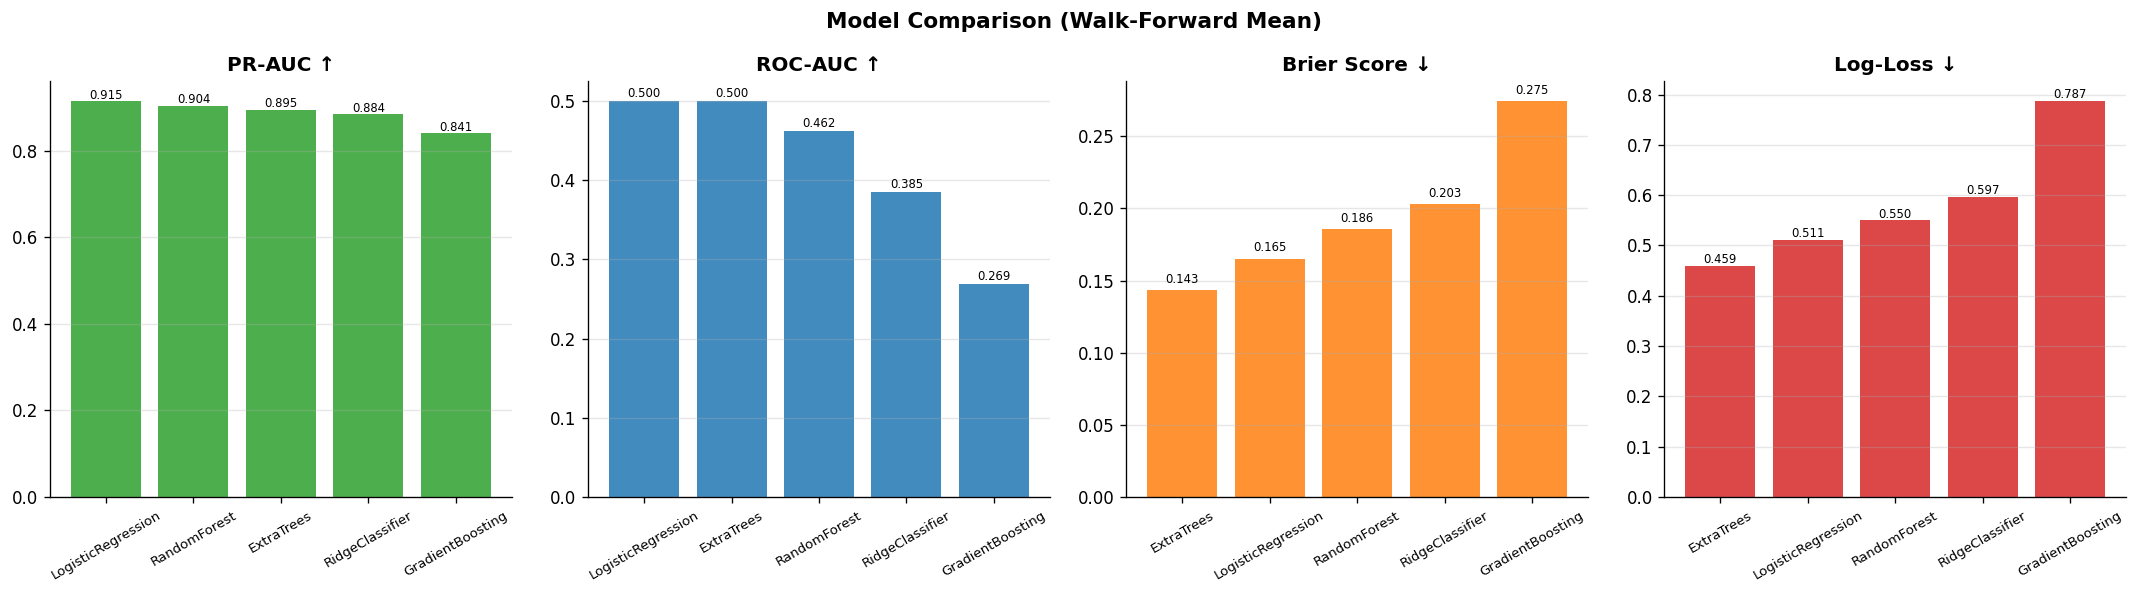

In [18]:
# ── Model comparison bar chart ─────────────────────────────────────────
metrics = ['pr_auc', 'roc_auc', 'brier', 'log_loss']
titles  = ['PR-AUC ↑', 'ROC-AUC ↑', 'Brier Score ↓', 'Log-Loss ↓']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison (Walk-Forward Mean)', fontsize=13, fontweight='bold')

for ax, metric, title, colour in zip(axes, metrics, titles,
                                      ['#2ca02c','#1f77b4','#ff7f0e','#d62728']):
    vals = summary[metric].dropna().sort_values(ascending=(metric in ['brier','log_loss']))
    bars = ax.bar(vals.index, vals.values, color=colour, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=7)

plt.tight_layout(); plt.show()


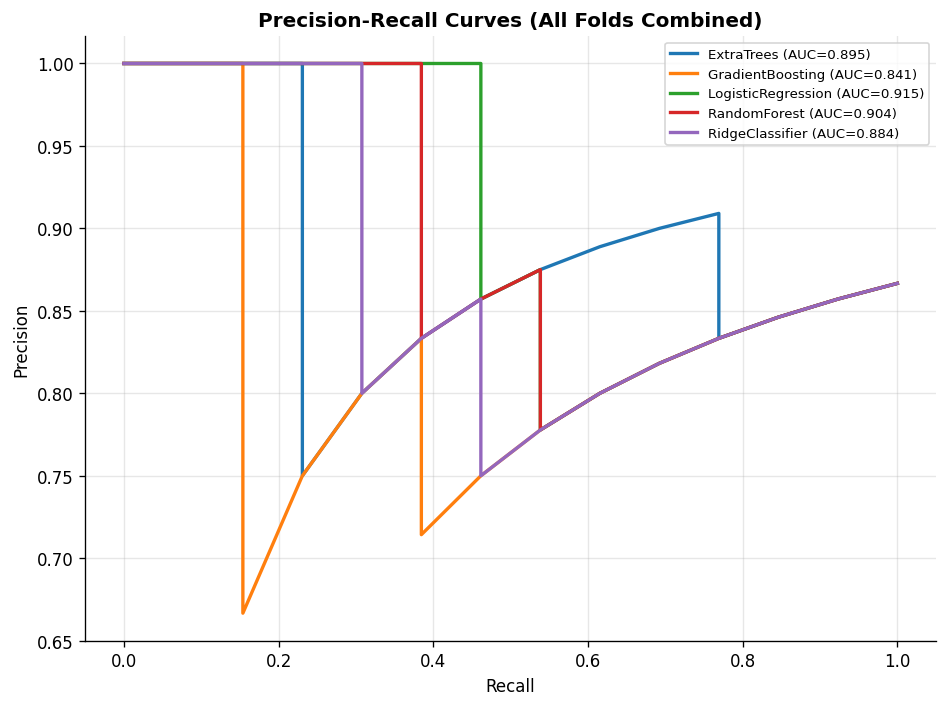

In [19]:
# ── Precision-Recall curves ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Precision-Recall Curves (All Folds Combined)', fontweight='bold')

for i, (model_name, grp) in enumerate(preds_df.groupby('model')):
    yt, yp = grp['y_true'].values, grp['y_prob'].values
    if yt.sum() == 0: continue
    prec, rec, _ = precision_recall_curve(yt, yp)
    auc_val = average_precision_score(yt, yp)
    ax.plot(rec, prec, linewidth=2, color=PALETTE[i%len(PALETTE)],
            label=f'{model_name} (AUC={auc_val:.3f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


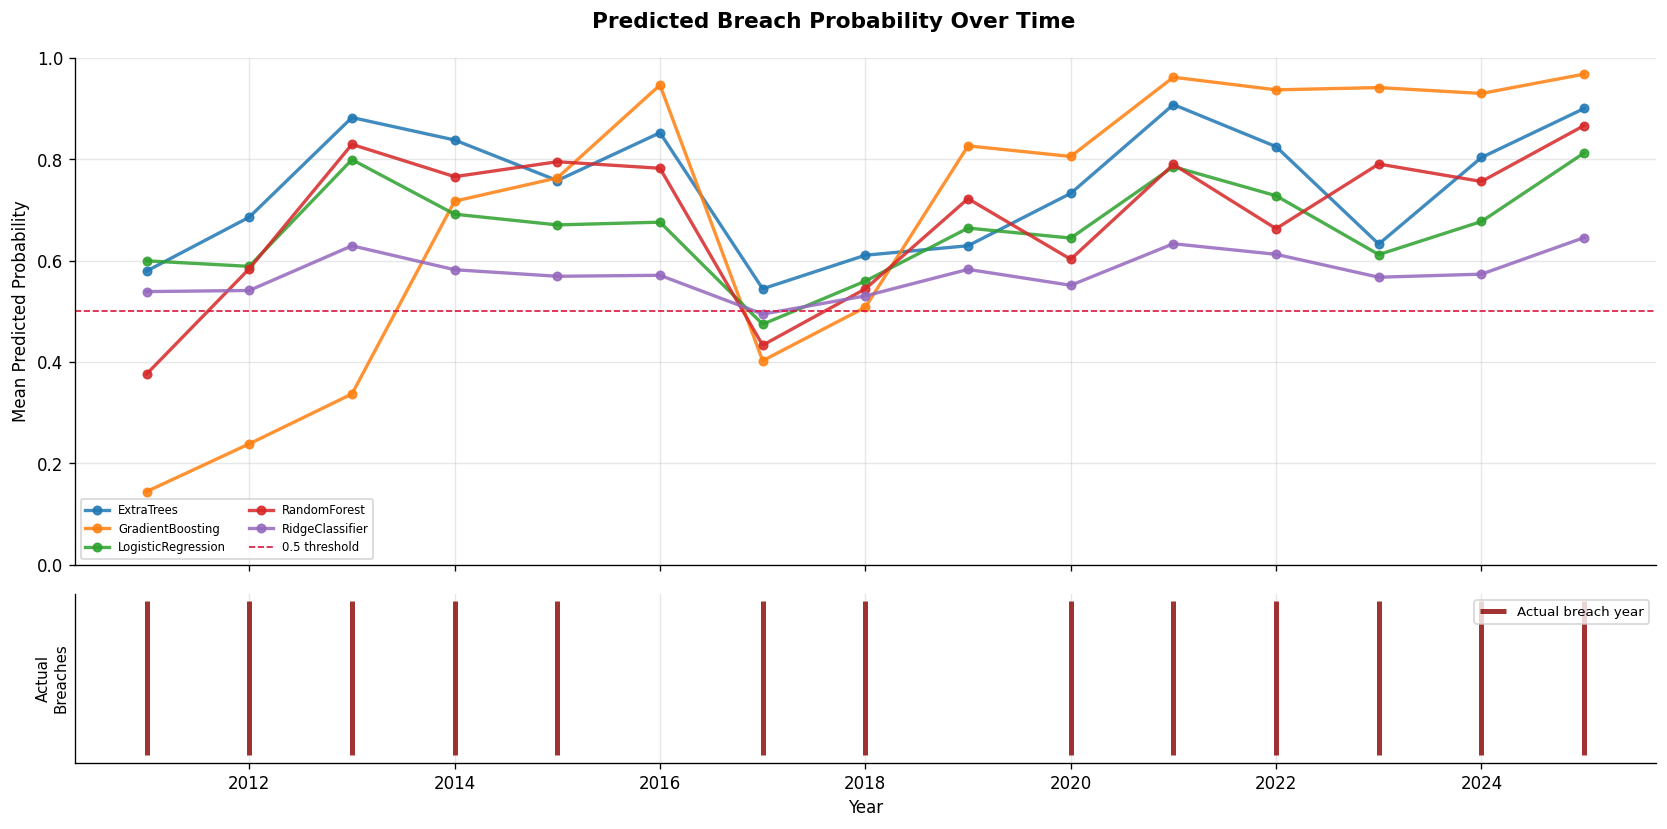

In [20]:
# ── Probability Timeline ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Predicted Breach Probability Over Time', fontsize=13, fontweight='bold')

for i, (mname, grp) in enumerate(preds_df.groupby('model')):
    yr_prob = grp.groupby('year')['y_prob'].mean()
    ax1.plot(yr_prob.index, yr_prob.values, 'o-', linewidth=2, markersize=5,
             color=PALETTE[i%len(PALETTE)], label=mname, alpha=0.85)

ax1.axhline(0.5, color='crimson', linestyle='--', linewidth=1, label='0.5 threshold')
ax1.set_ylabel('Mean Predicted Probability')
ax1.legend(fontsize=7, ncol=2); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1)

actual = preds_df.groupby('year')['y_true'].max()
ax2.vlines(actual[actual==1].index, 0, 1, color='darkred',
           linewidth=3, alpha=0.8, label='Actual breach year')
ax2.set_yticks([]); ax2.set_ylabel('Actual\nBreaches', fontsize=9)
ax2.set_xlabel('Year'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()


In [21]:
# ── Manual metric verification (Section 5.3 formulae) ─────────────────
from evaluation import brier_score, log_loss_manual

best_model_name = summary['pr_auc'].idxmax()
best_preds = preds_df[preds_df['model'] == best_model_name]
yt = best_preds['y_true'].values
yp = best_preds['y_prob'].values

print(f'Best model: {best_model_name}')
print(f'  Brier Score (manual):  {brier_score(yt, yp):.4f}')
print(f'  Log-Loss (manual):     {log_loss_manual(yt, yp):.4f}')
print(f'  PR-AUC:                {average_precision_score(yt, yp):.4f}')


Best model: LogisticRegression
  Brier Score (manual):  0.1651
  Log-Loss (manual):     0.5109
  PR-AUC:                0.9151


---
## 🧩 Stage 7 — Feature Explainability

Which societal/breach variables drive the model's predictions?

We use the **built-in feature importances** from Random Forest and
Gradient Boosting (tree-based SHAP equivalent).


In [22]:
# ── Feature importance: RF ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Mean Feature Importance Across Folds', fontsize=13, fontweight='bold')

for ax, mname in zip(axes, ['RandomForest', 'GradientBoosting']):
    fi = wfv.mean_feature_importance(mname)
    if fi.empty: ax.set_visible(False); continue
    top = fi.head(20)
    colours = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(top)))
    ax.barh(top.index[::-1], top.values[::-1], color=colours[::-1])
    ax.set_title(f'{mname}: Top-20 Features', fontweight='bold')
    ax.set_xlabel('Mean Importance')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()


In [23]:
# ── Cumulative importance (Pareto) ─────────────────────────────────────
fi_rf = wfv.mean_feature_importance('RandomForest')
if not fi_rf.empty:
    cum = fi_rf.cumsum() / fi_rf.sum() * 100
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(range(len(fi_rf)), fi_rf.values / fi_rf.sum() * 100,
           color='#1f77b4', alpha=0.7, label='Individual importance')
    ax2_twin = ax.twinx()
    ax2_twin.plot(range(len(cum)), cum.values, 'r-o', markersize=3, linewidth=2,
                  label='Cumulative')
    ax2_twin.axhline(80, color='grey', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(len(fi_rf)))
    ax.set_xticklabels(fi_rf.index, rotation=90, fontsize=7)
    ax.set_ylabel('Individual Importance (%)')
    ax2_twin.set_ylabel('Cumulative Importance (%)')
    ax.set_title('Random Forest — Pareto Feature Importance', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    n80 = (cum < 80).sum() + 1
    print(f'Features needed to explain 80% of variance: {n80}')
    plt.tight_layout(); plt.show()


In [24]:
# ── SHAP-style signed contribution (permutation approximation) ─────────
# We compute mean(pred | feat=high) - mean(pred | feat=low) for top features
best_fitted = wfv.best_models.get('RandomForest') or wfv.best_models.get('GradientBoosting')
if best_fitted is not None:
    fi_vals = wfv.mean_feature_importance('RandomForest')
    top_feats = fi_vals.head(8).index.tolist()

    signed_impacts = {}
    for feat in top_feats:
        if feat not in X.columns: continue
        X_hi = X.copy(); X_hi[feat] = X[feat].quantile(0.75)
        X_lo = X.copy(); X_lo[feat] = X[feat].quantile(0.25)
        try:
            p_hi = best_fitted.predict_proba(X_hi)[:, 1].mean()
            p_lo = best_fitted.predict_proba(X_lo)[:, 1].mean()
            signed_impacts[feat] = p_hi - p_lo
        except: pass

    si = pd.Series(signed_impacts).sort_values()
    colours = ['#d62728' if v > 0 else '#1f77b4' for v in si.values]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(si.index, si.values, color=colours)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Δ Predicted Probability (75th - 25th percentile)')
    ax.set_title('Directional Feature Impact (SHAP-Style Approximation)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    print('\nRed = feature increase RAISES breach probability')
    print('Blue = feature increase LOWERS breach probability')


---
## 🚨 Stage 8 — Risk Scoring & Alerts

Generate a **probability-based risk tier** for any given year's features.

| Tier | Probability | Action |
|------|-------------|--------|
| 🟢 LOW | < 40% | Routine monitoring |
| 🟡 ELEVATED | 40–60% | Enhanced vigilance |
| 🟠 HIGH | 60–80% | Active defence posture |
| 🔴 CRITICAL | ≥ 80% | Incident response readiness |


In [25]:
def risk_tier(prob):
    if prob >= 0.80: return '🔴 CRITICAL'
    if prob >= 0.60: return '🟠 HIGH'
    if prob >= 0.40: return '🟡 ELEVATED'
    return '🟢 LOW'

best_model_name = summary['pr_auc'].idxmax()
scored = preds_df[preds_df['model'] == best_model_name].copy()
scored['tier'] = scored['y_prob'].apply(risk_tier)

display(HTML(f'<b>Risk Scores — {best_model_name}</b>'))
display(
    scored[['year','y_prob','tier','y_true']]
    .rename(columns={'y_prob':'probability','y_true':'actual_breach'})
    .set_index('year')
    .style
    .background_gradient(subset=['probability'], cmap='RdYlGn_r')
    .map(lambda v: 'color: red; font-weight: bold' if v == 1 else '',
         subset=['actual_breach'])
    .format({'probability': '{:.1%}'})
)

,probability,tier,actual_breach
year,,,
2011,60.0%,🟡 ELEVATED,1
2012,58.9%,🟡 ELEVATED,1
2013,79.9%,🟠 HIGH,1
2014,69.2%,🟠 HIGH,1
2015,67.1%,🟠 HIGH,1
2016,67.6%,🟠 HIGH,0
2017,47.5%,🟡 ELEVATED,1
2018,56.0%,🟡 ELEVATED,1
2019,66.4%,🟠 HIGH,0


In [26]:
# ── Risk tier distribution visualisation ──────────────────────────────
tier_order = ['🟢 LOW', '🟡 ELEVATED', '🟠 HIGH', '🔴 CRITICAL']
tier_cnt   = scored['tier'].value_counts().reindex(tier_order, fill_value=0)
tier_col   = ['#2ca02c', '#f4d03f', '#ff7f0e', '#d62728']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Risk Score Summary — {best_model_name}', fontsize=13, fontweight='bold')

ax1.bar(tier_order, tier_cnt.values, color=tier_col, alpha=0.9, edgecolor='white')
ax1.set_ylabel('Years in Tier'); ax1.set_title('Risk Tier Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, (v, label) in enumerate(zip(tier_cnt.values, tier_order)):
    ax1.text(i, v+0.1, str(v), ha='center', fontweight='bold')

yr_prob_best = scored.set_index('year')['y_prob'].sort_index()
colours_line = [tier_col[['🟢 LOW','🟡 ELEVATED','🟠 HIGH','🔴 CRITICAL'].index(
                risk_tier(p))] for p in yr_prob_best.values]
ax2.bar(yr_prob_best.index, yr_prob_best.values, color=colours_line, alpha=0.85)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Year'); ax2.set_ylabel('Predicted Probability')
ax2.set_title('Yearly Risk Score Timeline')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


In [27]:
# ── Final summary printout ─────────────────────────────────────────────
from sklearn.metrics import brier_score_loss, log_loss, average_precision_score

yt = scored['y_true'].values
yp = scored['y_prob'].values

print('=' * 55)
print(f'  FINAL EVALUATION — {best_model_name}')
print('=' * 55)
print(f'  Brier Score : {brier_score_loss(yt, yp):.4f}')
print(f'  Log Loss    : {log_loss(yt, yp):.4f}')
print(f'  PR-AUC      : {average_precision_score(yt, yp):.4f}')
print('='*55)
print(f'\n  Records processed from ALL sources: {len(df):,}')
print(f'  Crypto-related incidents flagged:   {df["is_crypto"].sum():,}')
print(f'  Feature dimensions:                 {X.shape[1]}')
print(f'  Walk-forward folds:                 {len(wfv.all_results) // (len(models)+1)}')


  FINAL EVALUATION — LogisticRegression
  Brier Score : 0.1651
  Log Loss    : 0.5109
  PR-AUC      : 0.9151

  Records processed from ALL sources: 1,825
  Crypto-related incidents flagged:   61
  Feature dimensions:                 62
  Walk-forward folds:                 12


---
## 📦 Requirements

```
numpy>=1.24
pandas>=2.0
scikit-learn>=1.3
matplotlib>=3.7
jupyter
```

To run: `jupyter notebook Crypto_Breach_ML_Pipeline.ipynb`
